In [254]:
import helpers.Create_Target_Variable as Create_Target_Variable
import helpers.create_team_tendency_features as create_team_tendency_features
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

## Data Preparation

### Data Acquisition

In [255]:
# gather data
plays_df = pd.DataFrame()

plays_files = ['2017_plays.csv',
               '2018_plays.csv',
               '2019_plays.csv',
               '2020_plays.csv',
               '2021_plays.csv',
               '2022_plays.csv',
               '2023_plays.csv',
               '2024_plays.csv',
               '2025_plays.csv'
               ]

for file in plays_files:
    temp_df = pd.read_csv('Classify Plays/' + file)
    plays_df = pd.concat([plays_df, temp_df])

# Game ID for easy identification
def assign_game_id(row):
    season = row['Season']
    week = row['Week']
    home = row['HomeTeam']
    away = row['AwayTeam']

    return f'{season}_{week}_{home}_{away}'.replace(' ', '')

plays_df['GameID'] = plays_df.apply(assign_game_id, axis=1)

### Data Pre-processing

In [256]:
# map team with possesion to abbreviated name
full_name_map = {
    'Arizona Cardinals': 'ARI',
    'Dallas Cowboys': 'DAL',
    'Houston Texans': 'HOU',
    'Carolina Panthers': 'CAR',
    'Minnesota Vikings': 'MIN',
    'Buffalo Bills': 'BUF',
    'Miami Dolphins': 'MIA',
    'Atlanta Falcons': 'ATL',
    'Washington Commanders': 'WAS',
    'Baltimore Ravens': 'BAL',
    'Jacksonville Jaguars': 'JAX',
    'New England Patriots': 'NE',
    'Chicago Bears': 'CHI',
    'Denver Broncos': 'DEN',
    'New Orleans Saints': 'NO',
    'Cleveland Browns': 'CLE',
    'Green Bay Packers': 'GB',
    'Philadelphia Eagles': 'PHI',
    'Pittsburgh Steelers': 'PIT',
    'New York Giants': 'NYG',
    'Tampa Bay Buccaneers': 'TB',
    'Cincinnati Bengals': 'CIN',
    'Kansas City Chiefs': 'KC',
    'San Francisco 49ers': 'SF',
    'New York Jets': 'NYJ',
    'Tennessee Titans': 'TEN',
    'Los Angeles Rams': 'LAR',
    'Las Vegas Raiders': 'LV',
    'Detroit Lions': 'DET',
    'Indianapolis Colts': 'IND',
    'Los Angeles Chargers': 'LAC',
    'Seattle Seahawks': 'SEA'
}

short_name_map = {
    'Cardinals': 'ARI',
    'Cowboys': 'DAL',
    'Texans': 'HOU',
    'Panthers': 'CAR',
    'Vikings': 'MIN',
    'Bills': 'BUF',
    'Dolphins': 'MIA',
    'Falcons': 'ATL',
    'Commanders': 'WAS',
    'Redskins': 'WAS',
    'Football Team': 'WAS',
    'Ravens': 'BAL',
    'Jaguars': 'JAX',
    'Patriots': 'NE',
    'Bears': 'CHI',
    'Broncos': 'DEN',
    'Saints': 'NO',
    'Browns': 'CLE',
    'Packers': 'GB',
    'Eagles': 'PHI',
    'Steelers': 'PIT',
    'Giants': 'NYG',
    'Buccaneers': 'TB',
    'Bengals': 'CIN',
    'Chiefs': 'KC',
    '49ers': 'SF',
    'Jets': 'NYJ',
    'Titans': 'TEN',
    'Rams': 'LAR',
    'Raiders': 'LV',
    'Lions': 'DET',
    'Colts': 'IND',
    'Chargers': 'LAC',
    'Seahawks': 'SEA'
}

plays_df['TeamWithPossessionShort'] = plays_df['TeamWithPossession'].map(full_name_map)
plays_df['HomeTeamShort'] = plays_df['HomeTeam'].map(short_name_map)
plays_df['AwayTeamShort'] = plays_df['AwayTeam'].map(short_name_map)

In [257]:
# determine if home team has possession
plays_df['HomePossession'] = plays_df['TeamWithPossessionShort'] == plays_df['HomeTeamShort']

#### Calculate Current Score at each play start

In [258]:
# handle fumbles - determine which team recovered
plays_df['FumbleRecovery'] = (
    plays_df['PlayDescription']
        .str.extract(r"RECOVERED by ([A-Za-z]+)-")
)

In [259]:
# convert JAC to JAX and OAK to LV and LARC to LAR in FumbleRecovery field
plays_df['FumbleRecovery'] = plays_df['FumbleRecovery'].replace({
    'JAC': 'JAX',
    'OAK': 'LV',
    'LARC': 'LAR'
})

In [260]:
# score gain based on play outcome
score_gain_map = {
    'Touchdown': 6,
    'Extra Point': 1,
    'Field Goal': 3,
    'Safety' : 2,
    '2 Point Conversion': 2
}

plays_df['ScoreGain'] = plays_df['PlayOutcome'].map(score_gain_map).fillna(0)

In [261]:
# determine if offense or defense scored
def determine_team_scored(row):
    play_outcome = row['PlayOutcome']
    desc = row['PlayDescription']
    fumble_recovery = row['FumbleRecovery']
    poss_team = row['TeamWithPossessionShort']

    if play_outcome == 'Safety':
        return 'Defense'
    elif play_outcome in ['Field Goal', 'Extra Point', '2 Point Conversion']:
        return 'Offense'
    elif play_outcome == 'Touchdown':
        if 'FUMBLE' in desc:
            if fumble_recovery == poss_team:
                return 'Offense'
            else:
                return 'Defense'
        elif 'INTERCEPT' in desc:
            return 'Defense'
        else:
            return 'Offense'
    else:
        return 'No Score'
    
plays_df['TeamScored'] = plays_df.apply(determine_team_scored, axis=1)

In [262]:
# create bool columns for easier calc
plays_df['PossessionScore'] = plays_df['TeamScored'] == 'Offense'
plays_df['NonPossessionScore'] = plays_df['TeamScored'] == 'Defense'
plays_df['HomeScore'] = (plays_df['PossessionScore'] & plays_df['HomePossession']) | (plays_df['NonPossessionScore'] & ~plays_df['HomePossession'])
plays_df['AwayScore'] = (plays_df['PossessionScore'] & ~plays_df['HomePossession']) | (plays_df['NonPossessionScore'] & plays_df['HomePossession'])

In [263]:
# calc home score gain and away score gain at each play
plays_df['HomeScoreGain'] = plays_df['HomeScore'] * plays_df['ScoreGain']
plays_df['AwayScoreGain'] = plays_df['AwayScore'] * plays_df['ScoreGain']

In [264]:
# calculate cumulative sums of score gains
plays_df = plays_df.sort_values(['GameID', 'Quarter', 'DriveNumber', 'PlayNumberInDrive'])

plays_df['HomeScoreCum'] = (
    plays_df.groupby('GameID')['HomeScoreGain']
            .cumsum()
            .shift(1)
).fillna(0)

plays_df['AwayScoreCum'] = (
    plays_df.groupby('GameID')['AwayScoreGain']
            .cumsum()
            .shift(1)
).fillna(0)

#### Further Cleaning

In [265]:
# drop rows where PlayStart is null - irrelevant data
plays_df.dropna(subset=['PlayStart'], inplace=True)

# drop sacks and penalty plays - can't classify a play call
plays_df = plays_df[~plays_df['PlayOutcome'].str.contains('sack|penalty', case=False, na=False)]

# remove 'Hall Of Fame' and 'Preseason' games
plays_df = plays_df[~plays_df['Week'].str.contains('Hall Of Fame|Preseason|18|Wild|Conference|Divisional|Super', na=False)]

# remove the 'Week' prefix
plays_df['Week'] = plays_df['Week'].str[-2:].str.strip()
# Convert Week to int
plays_df['Week'] = plays_df['Week'].astype(int)

### Target Variable Creation

In [266]:
# create target variable: play call
plays_df['PlayCall'] = plays_df.apply(Create_Target_Variable.classify_play_call, axis=1)

In [267]:
# drop where play cannot be classified
plays_df.dropna(subset=['PlayCall'], inplace=True)

### Feature Engineering

In [268]:
### extract data from PlayStart field e.g. "3rd & 1 at LAC 1" ###

# split before and after " at "
temp = plays_df['PlayStart'].str.split(' at ', expand=True)
left = temp[0]   # "3rd & 1"
right = temp[1]  # "LAC 1"

# extract Down and YdsTo1stDown
plays_df['Down'] = left.str.extract(r'(\d+)').astype(int)
plays_df['YdsTo1stDown'] = left.str.extract(r'&\s*(\d+)').astype(int)

# extract Territory and YdPosition
plays_df['Territory'] = right.str.extract(r'([A-Z]+)')
plays_df['YdPosition'] = right.str.extract(r'(\d+)').astype(int)

In [269]:
# convert JAC to JAX and OAK to LV in Territory field
plays_df['Territory'] = plays_df['Territory'].replace({
    'JAC': 'JAX',
    'OAK': 'LV'
})

In [270]:
# calculate yards to enzone
def get_yds_to_endzone(row):
    if row['YdPosition'] == 50:
        return 50
    elif row['Territory'] == row['TeamWithPossessionShort']:
        return row['YdPosition'] + 50
    else:
        return row['YdPosition']

plays_df['YdsToEndzone'] = plays_df.apply(get_yds_to_endzone, axis=1)

In [271]:
# calculate minutes remaining in game as a float
def extract_minutes(time_str):
    # convert mm:ss to float minutes.
    minutes, seconds = time_str.split(':')
    return int(minutes) + int(seconds) / 60

def compute_min_remaining(row):
    # extract the mm:ss at the start of PlayTimeFormation
    time_part = row['PlayTimeFormation'].split()[0]   # e.g., "14:49"
    minutes_left = extract_minutes(time_part)

    quarter = row['Quarter']

    if quarter == '4th Quarter' or quarter == 'Overtime':
        return minutes_left
    elif quarter == '3rd Quarter':
        return minutes_left + 15
    elif quarter == '2nd Quarter':
        return minutes_left + 30
    elif quarter == '1st Quarter':
        return minutes_left + 45
    else:
        return None  # in case of unexpected values

# apply the function to create MinRemaining
plays_df['MinRemaining'] = plays_df.apply(compute_min_remaining, axis=1)

In [272]:
# add ScoreDiff feature: possession team score - other team score
# this tells us how behind or ahead the team is
plays_df['ScoreDiff'] = np.where(
    plays_df['HomePossession'],
    plays_df['HomeScoreCum'] - plays_df['AwayScoreCum'],   # home has possession
    plays_df['AwayScoreCum'] - plays_df['HomeScoreCum']    # away has possession
)

In [273]:
# Calculate global means for fallback (using all seasons data)
global_means = create_team_tendency_features.calculate_season_means(plays_df, season=None)

LEAGUE AVERAGES FOR ALL SEASONS
Run         : 43.87%
Short_Pass  : 51.27%
Long_Pass   :  4.86%



In [274]:
# Add team tendency features for each season
all_seasons_with_features = []

for year in range(2017, 2026):  # 2017-2025
    print(f"\nProcessing {year}...")
    
    # Get current season data
    df_season = plays_df[plays_df['Season'] == year].copy()
    
    # Get previous season data (None for 2017)
    if year == 2017:
        df_previous = None
        print(f"  Using global means (first season)")
    else:
        df_previous = plays_df[plays_df['Season'] == (year - 1)].copy()
        print(f"  Using {year-1} season data for early weeks")
    
    # Add features
    df_with_features = create_team_tendency_features.add_team_tendency_features(
        df_season=df_season,
        df_previous_season=df_previous,
        global_means=global_means,
        team_col='TeamWithPossessionShort'
    )
    
    all_seasons_with_features.append(df_with_features)

# Combine all seasons back together
plays_df = pd.concat(all_seasons_with_features, ignore_index=True)

print(f"Added features to {len(plays_df):,} plays")
print(f"New columns: team_run_pct, team_short_pass_pct, team_long_pass_pct")


Processing 2017...
  Using global means (first season)

Processing 32 teams for season 2017...
Added team tendency features for 32 teams

Processing 2018...
  Using 2017 season data for early weeks

Processing 32 teams for season 2018...
Added team tendency features for 32 teams

Processing 2019...
  Using 2018 season data for early weeks

Processing 32 teams for season 2019...
Added team tendency features for 32 teams

Processing 2020...
  Using 2019 season data for early weeks

Processing 32 teams for season 2020...
Added team tendency features for 32 teams

Processing 2021...
  Using 2020 season data for early weeks

Processing 32 teams for season 2021...
Added team tendency features for 32 teams

Processing 2022...
  Using 2021 season data for early weeks

Processing 32 teams for season 2022...
Added team tendency features for 32 teams

Processing 2023...
  Using 2022 season data for early weeks

Processing 32 teams for season 2023...
Added team tendency features for 32 teams

Pro

In [275]:
print(plays_df.columns)

Index(['Season', 'Week', 'Day', 'Date', 'AwayTeam', 'HomeTeam', 'Quarter',
       'DriveNumber', 'TeamWithPossession', 'IsScoringDrive',
       'PlayNumberInDrive', 'IsScoringPlay', 'PlayOutcome', 'PlayStart',
       'PlayTimeFormation', 'PlayDescription', 'GameID',
       'TeamWithPossessionShort', 'HomeTeamShort', 'AwayTeamShort',
       'HomePossession', 'FumbleRecovery', 'ScoreGain', 'TeamScored',
       'PossessionScore', 'NonPossessionScore', 'HomeScore', 'AwayScore',
       'HomeScoreGain', 'AwayScoreGain', 'HomeScoreCum', 'AwayScoreCum',
       'PlayCall', 'Down', 'YdsTo1stDown', 'Territory', 'YdPosition',
       'YdsToEndzone', 'MinRemaining', 'ScoreDiff', 'GameId', 'team_run_pct',
       'team_short_pass_pct', 'team_long_pass_pct'],
      dtype='object')


In [276]:
# Add team tendency features for each season
all_seasons_with_features = []

for year in range(2017, 2026):  # 2017-2025
    print(f"\nProcessing {year}...")
    
    # Get current season data
    df_season = plays_df[plays_df['Season'] == year].copy()
    
    # Get previous season data (None for 2017)
    if year == 2017:
        df_previous = None
        print(f"  Using global means (first season)")
    else:
        df_previous = plays_df[plays_df['Season'] == (year - 1)].copy()
        print(f"  Using {year-1} season data for early weeks")
    
    # Add features
    df_with_features = create_team_tendency_features.add_team_tendency_features(
        df_season=df_season,
        df_previous_season=df_previous,
        global_means=global_means,
        team_col='TeamWithPossessionShort'
    )
    
    all_seasons_with_features.append(df_with_features)

# Combine all seasons back together
plays_df = pd.concat(all_seasons_with_features, ignore_index=True)

print(f"Added features to {len(plays_df):,} plays")
print(f"New columns: team_run_pct, team_short_pass_pct, team_long_pass_pct")


Processing 2017...
  Using global means (first season)

Processing 32 teams for season 2017...
Added team tendency features for 32 teams

Processing 2018...
  Using 2017 season data for early weeks

Processing 32 teams for season 2018...
Added team tendency features for 32 teams

Processing 2019...
  Using 2018 season data for early weeks

Processing 32 teams for season 2019...
Added team tendency features for 32 teams

Processing 2020...
  Using 2019 season data for early weeks

Processing 32 teams for season 2020...
Added team tendency features for 32 teams

Processing 2021...
  Using 2020 season data for early weeks

Processing 32 teams for season 2021...
Added team tendency features for 32 teams

Processing 2022...
  Using 2021 season data for early weeks

Processing 32 teams for season 2022...
Added team tendency features for 32 teams

Processing 2023...
  Using 2022 season data for early weeks

Processing 32 teams for season 2023...
Added team tendency features for 32 teams

Pro

## Data Visualization

In [277]:
clean_df = plays_df[["DriveNumber", "PlayCall", "Down", "YdsTo1stDown", "YdsToEndzone", "MinRemaining", "ScoreDiff", "team_run_pct", "team_short_pass_pct", "team_long_pass_pct"]]
print(clean_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285588 entries, 0 to 285587
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   DriveNumber          285588 non-null  int64  
 1   PlayCall             285588 non-null  object 
 2   Down                 285588 non-null  int64  
 3   YdsTo1stDown         285588 non-null  int64  
 4   YdsToEndzone         285588 non-null  int64  
 5   MinRemaining         285588 non-null  float64
 6   ScoreDiff            285588 non-null  float64
 7   team_run_pct         285588 non-null  float64
 8   team_short_pass_pct  285588 non-null  float64
 9   team_long_pass_pct   285588 non-null  float64
dtypes: float64(5), int64(4), object(1)
memory usage: 21.8+ MB
None


In [278]:
clean_df['PlayCall'].unique()

array(['Short_Pass', 'Run', 'Long_Pass', 'Field_Goal', 'Punt', 'Spike'],
      dtype=object)

In [279]:
# save/create clean_df as a csv in our current directory, if it already exists then update it 
clean_df.to_csv('clean_plays_data.csv', index=False)
print("Data saved to clean_plays_data.csv")

Data saved to clean_plays_data.csv


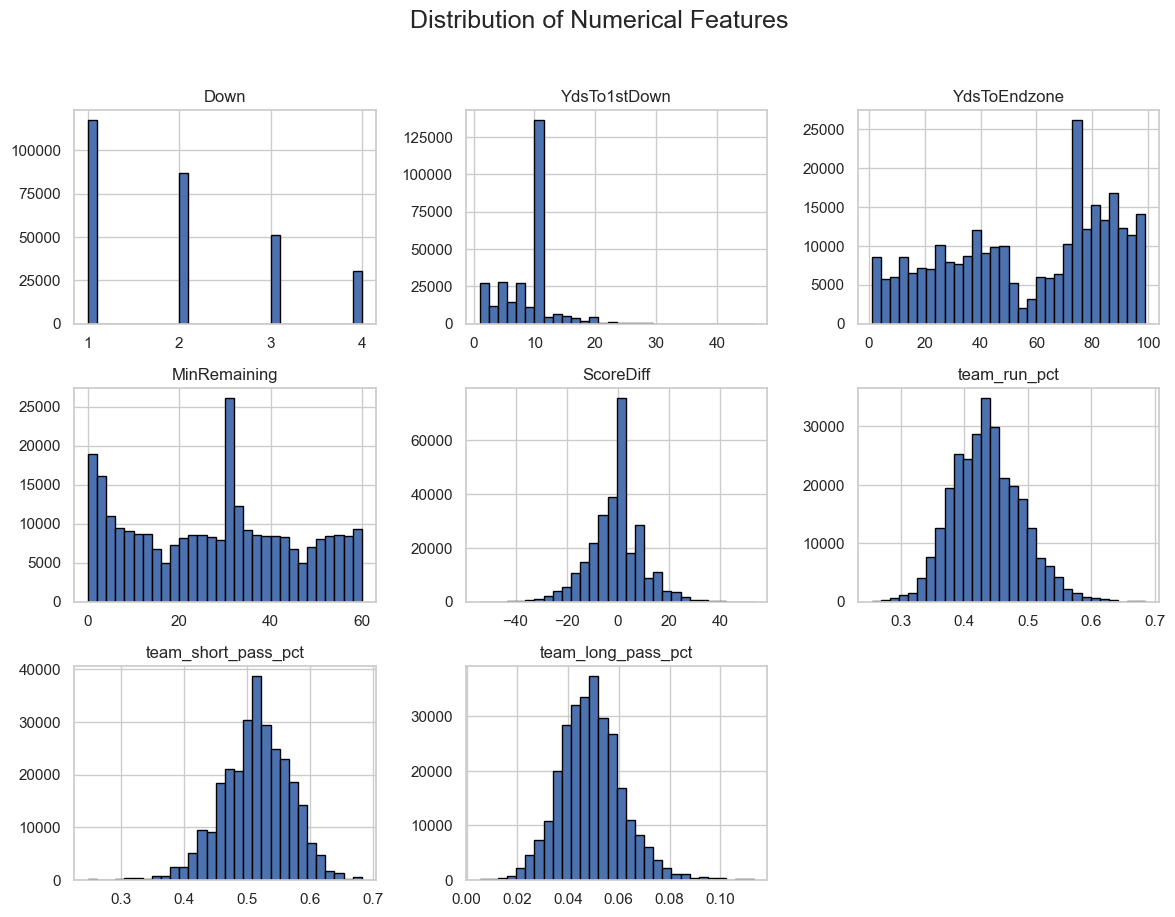

In [280]:
num_cols = ['Down', 'YdsTo1stDown', 'YdsToEndzone', 'MinRemaining', 'ScoreDiff',
            'team_run_pct', 'team_short_pass_pct', 'team_long_pass_pct']

clean_df[num_cols].hist(bins=30, figsize=(14,10), edgecolor='black')
plt.suptitle("Distribution of Numerical Features", fontsize=18)
plt.show()

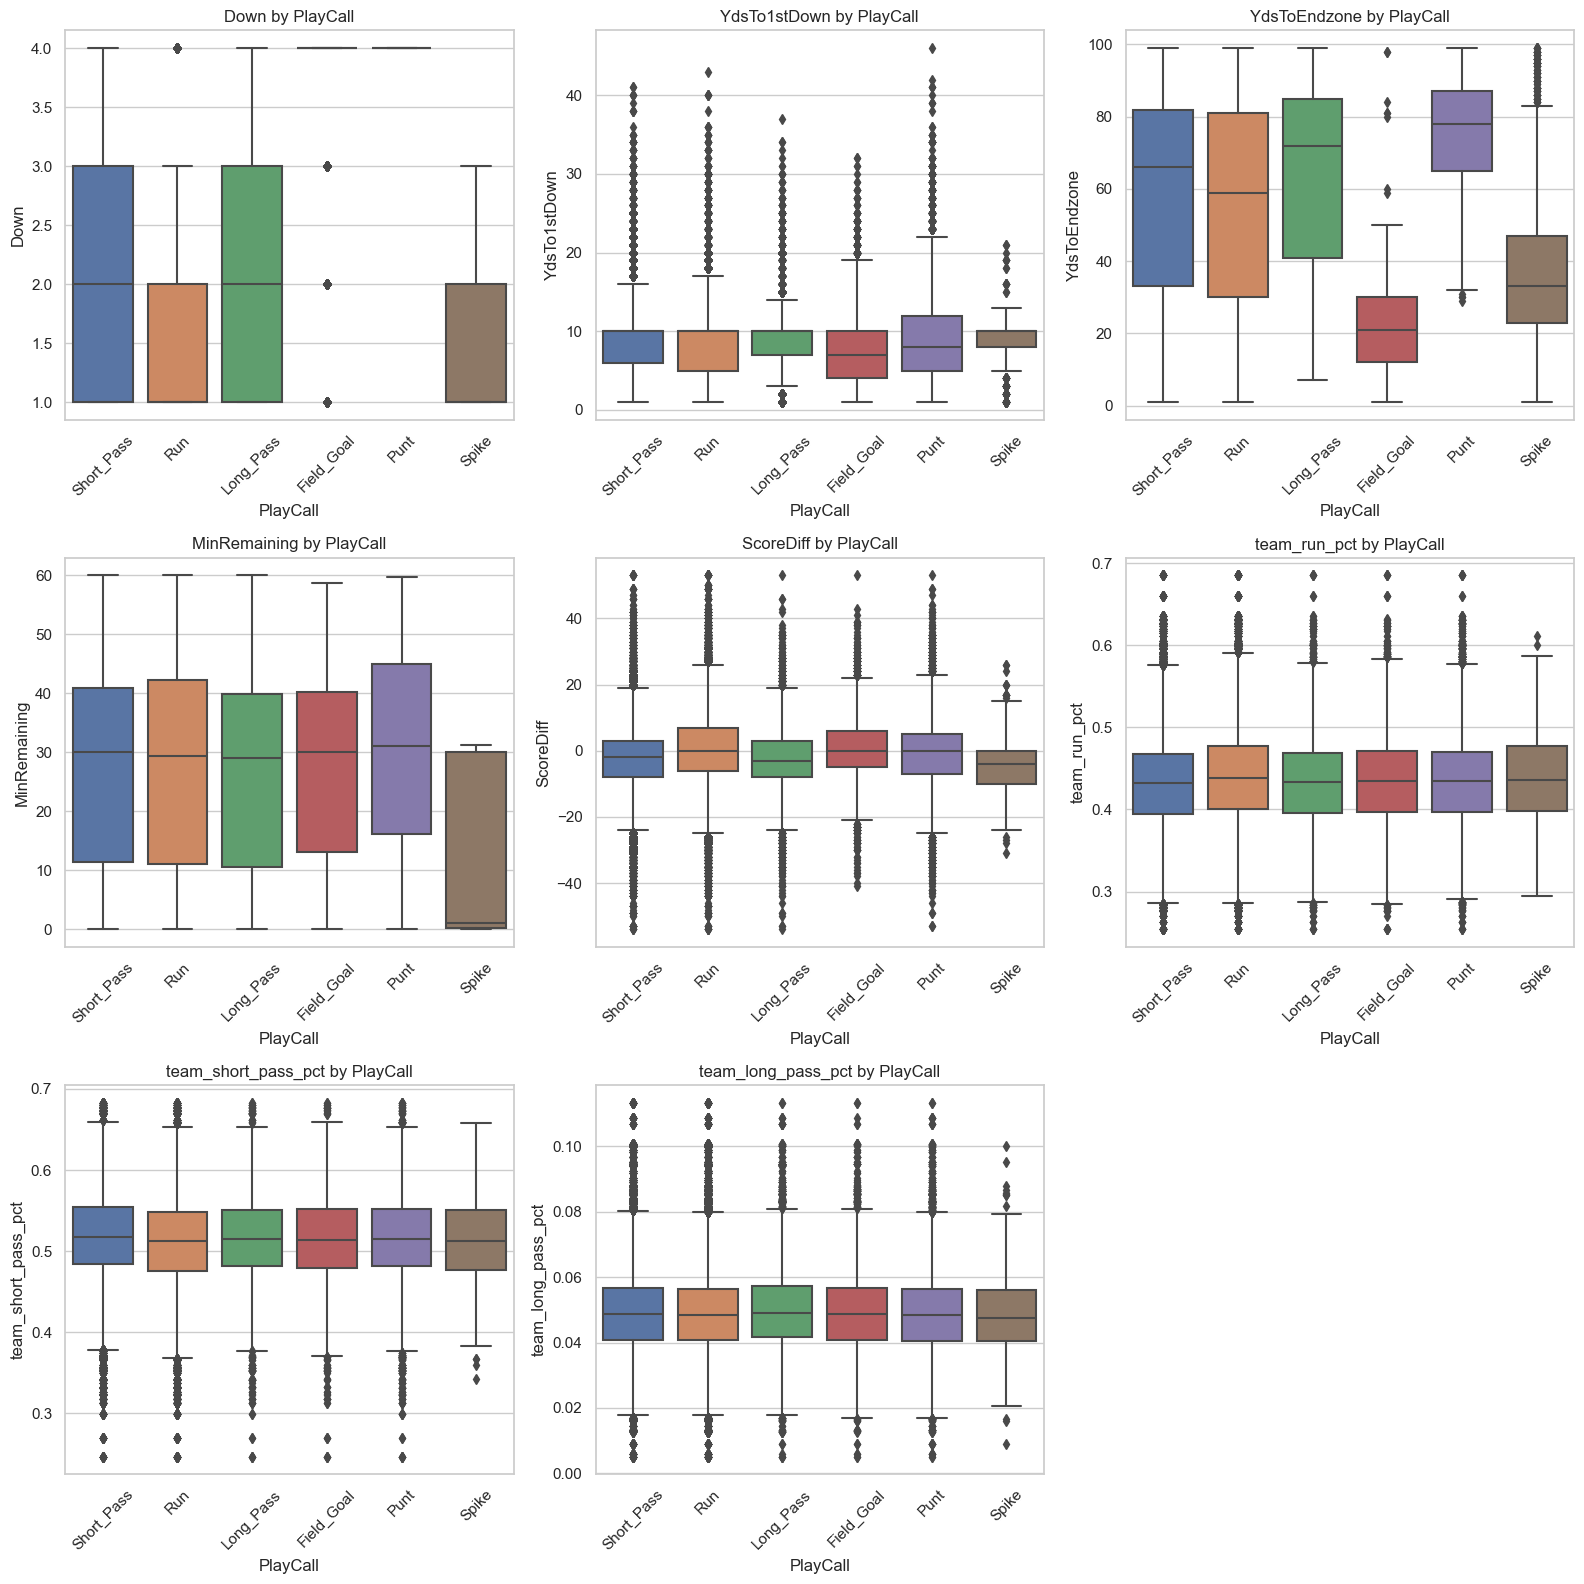

In [281]:
plt.figure(figsize=(16,16))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=clean_df, x='PlayCall', y=col)
    plt.xticks(rotation=45)
    plt.title(f"{col} by PlayCall")

plt.tight_layout()
plt.show()


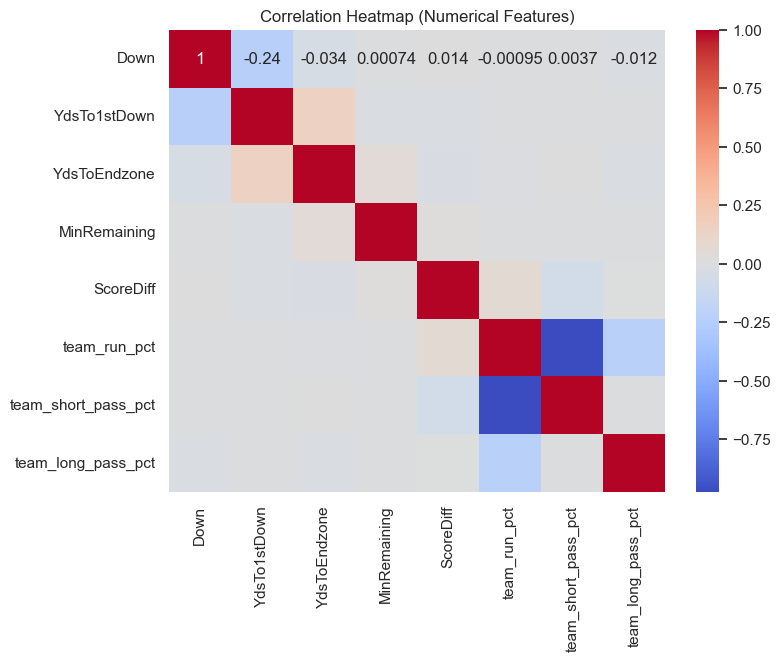

In [282]:
plt.figure(figsize=(8,6))
sns.heatmap(clean_df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

It is important to note here that the features have low correlation with each other, which is good for our model.

             Count  Percent
PlayCall                   
Short_Pass  132858    46.52
Run         113695    39.81
Punt         17516     6.13
Long_Pass    12600     4.41
Field_Goal    8346     2.92
Spike          573     0.20


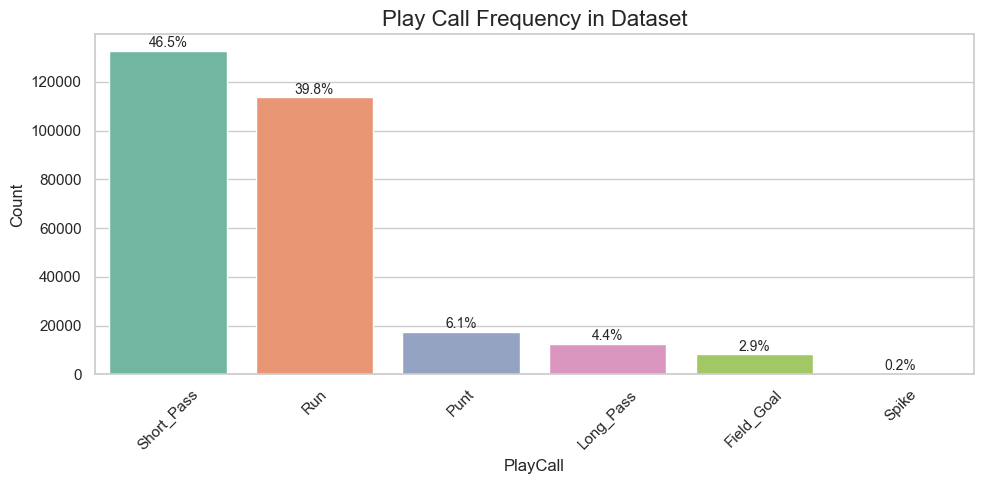

In [284]:
# count each play call
play_counts = clean_df['PlayCall'].value_counts()
play_percent = clean_df['PlayCall'].value_counts(normalize=True) * 100

# combine into a dataframe
freq_df = pd.DataFrame({
    'Count': play_counts,
    'Percent': play_percent.round(2)
})

print(freq_df)

plt.figure(figsize=(10,5))
sns.barplot(
    x=play_counts.index,
    y=play_counts.values,
    palette="Set2"
)

plt.title("Play Call Frequency in Dataset", fontsize=16)
plt.ylabel("Count")
plt.xlabel("PlayCall")
plt.xticks(rotation=45)

# annotate the bars with percentages
for i, v in enumerate(play_counts.values):
    pct = play_percent.iloc[i]
    plt.text(i, v + max(play_counts)*0.01, f"{pct:.1f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Play Call Prediction & Testing

### Model Creation

In [285]:
sns.set(style="whitegrid")

# Features & target
feature_cols = ['Down', 'YdsTo1stDown', 'YdsToEndzone', 'MinRemaining', 'ScoreDiff',
                'team_run_pct', 'team_short_pass_pct', 'team_long_pass_pct']
X = clean_df[feature_cols].copy()
y = clean_df['PlayCall'].copy()

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = le.classes_
print("Classes:", list(class_names))

# train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.25, random_state=42, stratify=y_enc
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

# models definition
models = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(multi_class='multinomial', solver='saga', max_iter=5000, random_state=42))
    ]),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, random_state=42)
}

Classes: ['Field_Goal', 'Long_Pass', 'Punt', 'Run', 'Short_Pass', 'Spike']
Train size: (214191, 8) Test size: (71397, 8)


### Model Testing & Evaluation

In [286]:
# train, predict and evaluate
results = {}
for name, model in models.items():
    print(f"\nTraining {name} ...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    print(f"{name} accuracy: {acc:.4f}  macro-precision: {prec:.4f}  recall: {rec:.4f}  f1: {f1:.4f}")
    print("Classification report:\n", classification_report(y_test, y_pred, target_names=class_names, zero_division=0))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'accuracy': acc,
        'precision_macro': prec,
        'recall_macro': rec,
        'f1_macro': f1
    }


Training LogisticRegression ...


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression accuracy: 0.6282  macro-precision: 0.4814  recall: 0.5026  f1: 0.4917
Classification report:
               precision    recall  f1-score   support

  Field_Goal       0.78      0.79      0.79      2087
   Long_Pass       0.00      0.00      0.00      3150
        Punt       0.90      0.97      0.93      4379
         Run       0.58      0.61      0.60     28424
  Short_Pass       0.62      0.65      0.64     33214
       Spike       0.00      0.00      0.00       143

    accuracy                           0.63     71397
   macro avg       0.48      0.50      0.49     71397
weighted avg       0.60      0.63      0.61     71397

Confusion matrix:
 [[ 1645     0   103    64   275     0]
 [   15     0    24  1045  2066     0]
 [   22     0  4233     0   124     0]
 [  184     0   138 17247 10855     0]
 [  229     0   208 11048 21729     0]
 [    1     0     0    93    49     0]]

Training RandomForest ...
RandomForest accuracy: 0.6602  macro-precision: 0.5941  recall:

### Hyperparameter Tuning with Grid Search

We use GridSearchCV to systematically search for optimal hyperparameters for our tree-based models. This helps improve model performance by finding the best combination of parameters through cross-validation.


In [287]:
from sklearn.model_selection import GridSearchCV

# Define parameter grids for tuning (reduced for efficiency with large dataset)
# RandomForest: 2 × 3 × 2 = 12 combinations × 3 CV = 36 fits
# GradientBoosting: 2 × 2 × 2 = 8 combinations × 3 CV = 24 fits
param_grids = {
    'RandomForest': {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    },
    'GradientBoosting': {
        'n_estimators': [100, 200],
        'max_depth': [3, 5],
        'learning_rate': [0.05, 0.1]
    }
}

# Store tuning results
tuning_results = {}

# Perform grid search for each model
for name, param_grid in param_grids.items():
    print(f"\n{'='*60}")
    print(f"Tuning {name}...")
    print(f"{'='*60}")
    
    if name == 'RandomForest':
        base_model = RandomForestClassifier(random_state=42, n_jobs=-1)
    else:
        base_model = GradientBoostingClassifier(random_state=42)
    
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=3,  # 3-fold cross-validation
        scoring='f1_macro',  # optimize for macro F1 due to class imbalance
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    # Get best model and evaluate
    best_model = grid_search.best_estimator_
    y_pred_tuned = best_model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred_tuned)
    f1 = f1_score(y_test, y_pred_tuned, average='macro', zero_division=0)
    
    print(f"\nBest parameters: {grid_search.best_params_}")
    print(f"Best CV F1 score: {grid_search.best_score_:.4f}")
    print(f"Test accuracy: {acc:.4f}")
    print(f"Test F1 (macro): {f1:.4f}")
    
    tuning_results[name] = {
        'best_params': grid_search.best_params_,
        'best_cv_score': grid_search.best_score_,
        'test_accuracy': acc,
        'test_f1': f1,
        'best_model': best_model
    }

print("\n" + "="*60)
print("GRID SEARCH COMPLETE")
print("="*60)



Tuning RandomForest...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1 score: 0.5261
Test accuracy: 0.6724
Test F1 (macro): 0.5312

Tuning GradientBoosting...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
Best CV F1 score: 0.5446
Test accuracy: 0.6753
Test F1 (macro): 0.5527

GRID SEARCH COMPLETE


In [288]:
# Compare tuned vs original model performance
print("="*70)
print("COMPARISON: Original vs Tuned Models")
print("="*70)

comparison_data = []
for name in ['RandomForest', 'GradientBoosting']:
    original = results[name]
    tuned = tuning_results[name]
    
    comparison_data.append({
        'Model': f'{name} (Original)',
        'Accuracy': original['accuracy'],
        'F1 (macro)': original['f1_macro']
    })
    comparison_data.append({
        'Model': f'{name} (Tuned)',
        'Accuracy': tuned['test_accuracy'],
        'F1 (macro)': tuned['test_f1']
    })

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

# Display best parameters found
print("\n" + "="*70)
print("BEST HYPERPARAMETERS FOUND")
print("="*70)
for name, result in tuning_results.items():
    print(f"\n{name}:")
    for param, value in result['best_params'].items():
        print(f"  {param}: {value}")

# Update results dictionary with tuned models for downstream analysis
print("\n" + "="*70)
print("Updating results with tuned models...")
print("="*70)
for name in ['RandomForest', 'GradientBoosting']:
    best_model = tuning_results[name]['best_model']
    y_pred_tuned = best_model.predict(X_test)
    
    # Update results with tuned model metrics
    results[name] = {
        'model': best_model,
        'y_pred': y_pred_tuned,
        'accuracy': tuning_results[name]['test_accuracy'],
        'precision_macro': precision_score(y_test, y_pred_tuned, average='macro', zero_division=0),
        'recall_macro': recall_score(y_test, y_pred_tuned, average='macro', zero_division=0),
        'f1_macro': tuning_results[name]['test_f1']
    }
    print(f"  {name} updated with best tuned model (F1: {results[name]['f1_macro']:.4f})")


COMPARISON: Original vs Tuned Models


,Model,Accuracy,F1 (macro)
0,RandomForest (Original),0.660168,0.527825
1,RandomForest (Tuned),0.672381,0.531170
2,GradientBoosting (Original),0.674636,0.547846
3,GradientBoosting (Tuned),0.675336,0.552720



BEST HYPERPARAMETERS FOUND

RandomForest:
  max_depth: 20
  min_samples_split: 5
  n_estimators: 100

GradientBoosting:
  learning_rate: 0.05
  max_depth: 5
  n_estimators: 100

Updating results with tuned models...
  RandomForest updated with best tuned model (F1: 0.5312)
  GradientBoosting updated with best tuned model (F1: 0.5527)


### Results Comparison

In [289]:
# comparison table
cmp_df = pd.DataFrame([
    {
        'model': name,
        'accuracy': v['accuracy'],
        'precision_macro': v['precision_macro'],
        'recall_macro': v['recall_macro'],
        'f1_macro': v['f1_macro']
    }
    for name, v in results.items()
]).set_index('model')

print("=== Model comparison (on test set) ===")
display(cmp_df)

=== Model comparison (on test set) ===


,accuracy,precision_macro,recall_macro,f1_macro
model,,,,
LogisticRegression,0.628234,0.481353,0.502643,0.491681
RandomForest,0.672381,0.601500,0.534739,0.531170
GradientBoosting,0.675336,0.562721,0.556575,0.552720


### Feature Importances

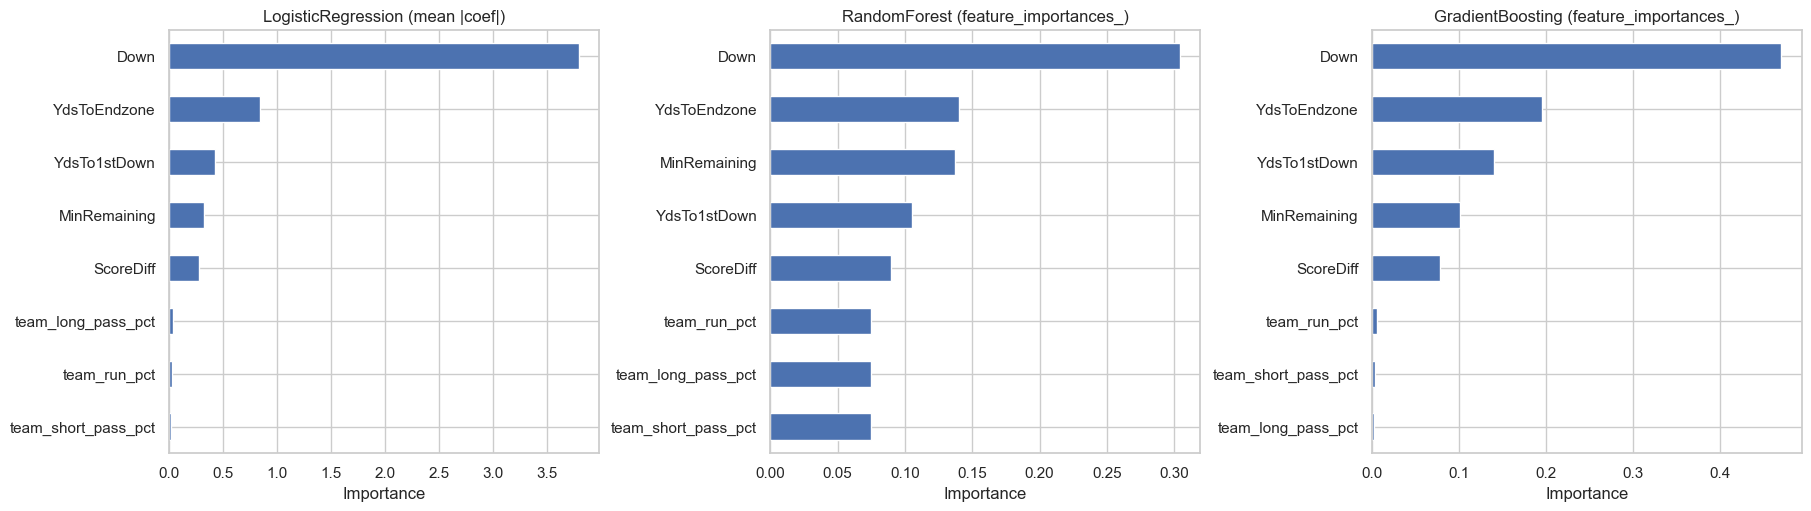

In [290]:
# feature importances
def plot_feature_importances(importances, feature_names, title, ax=None):
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=True)
    if ax is None:
        plt.figure(figsize=(6,4))
        fi.plot(kind='barh')
        plt.title(title)
        plt.xlabel('Importance')
        plt.show()
    else:
        fi.plot(kind='barh', ax=ax)
        ax.set_title(title)
        ax.set_xlabel('Importance')

# get importances for each model
fig, axes = plt.subplots(1, 3, figsize=(18,5), constrained_layout=True)
for ax, (name, res) in zip(axes, results.items()):
    model = res['model']
    if name == 'LogisticRegression':
        # get coef_ from the logistic step
        clf = model.named_steps['clf']
        coefs = clf.coef_   # shape: (n_classes, n_features)
        # Use mean absolute coefficient across classes as importance
        importances = np.mean(np.abs(coefs), axis=0)
        plot_feature_importances(importances, feature_cols, title=f"{name} (mean |coef|)", ax=ax)
    elif name == 'RandomForest':
        importances = model.feature_importances_
        plot_feature_importances(importances, feature_cols, title=f"{name} (feature_importances_)", ax=ax)
    elif name == 'GradientBoosting':
        importances = model.feature_importances_
        plot_feature_importances(importances, feature_cols, title=f"{name} (feature_importances_)", ax=ax)

plt.show()

In [291]:
# top features per model in tables
for name, res in results.items():
    model = res['model']
    if name == 'LogisticRegression':
        coefs = model.named_steps['clf'].coef_
        importances = np.mean(np.abs(coefs), axis=0)
    else:
        importances = model.feature_importances_
    fi = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
    print(f"\nTop features for {name}:")
    display(fi.to_frame(name='importance').head(6))


Top features for LogisticRegression:


,importance
Down,3.789470
YdsToEndzone,0.844661
YdsTo1stDown,0.425432
MinRemaining,0.322437
ScoreDiff,0.276837
team_long_pass_pct,0.033495



Top features for RandomForest:


,importance
Down,0.304350
YdsToEndzone,0.139897
MinRemaining,0.137236
YdsTo1stDown,0.105316
ScoreDiff,0.089427
team_run_pct,0.074742



Top features for GradientBoosting:


,importance
Down,0.470465
YdsToEndzone,0.195506
YdsTo1stDown,0.140115
MinRemaining,0.101996
ScoreDiff,0.078690
team_run_pct,0.005886


## Conclusion

Overall, our model worked relatively well, with Gradient Boosting having the best performance with predicting play calls. All of our features needed to be engineered in some fashion and this proved to be worth it in the end, as our engineered features were successful. This algorithm would be useful for NFL teams to use to narrow down which type of play to call in a given game situation. This would also be useful for sports analysts when analyzing games and team decision, and would give commentators some insights as well. This model could definitely be made more sophisticated in a variety of ways. One way would be to get more specific on the play calls. For simplicity purposes, we kept it to 6 types of play calls that were very general. Another thing we could do to improve would be to grade team's offensive and defensive efficiency for certain types of plays. For example, if a team has a highly rated secondary defense, then the team with posession might be less likely to pass. Similarly, a QB like Jalen Hurts would be more likley to run than a QB like Jared Goff. Adding these grades would cater the algorithm to specific teams to utilize or specific things for commentator and analysts to look for in a certain matchup.

### Workload Distribution

Both
- Data Acquisition & Pre-processing
- Feature Engineering
- Strategy & Organization

Mason Ricci
- Origanization of GitHub & PowerPoint
- Target Variable Creation (classifying play calls)
- Feature Engineering: team_run_pct, team_short_pass_pct, team_long_pass_pct
- Hyperparameter Tuning with Grid Search

Mary Sullivan
- Project Concept
- Cumulative Score Calculations
- Feature Engineering: Down, YdsTo1stDown, YdsToEndzone, MinRemaining, ScoreDiff
- Data Visualization
- Initial train & test of Logistic Regression, Random Forest and Gradient Boosting models